In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/daily_sales.csv")

In [3]:
df['ds'] = pd.to_datetime(df['ds'])

In [4]:
data = df[['y']]

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [6]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):

        X.append(data[i-seq_length:i])

        y.append(data[i])

    return np.array(X), np.array(y)

In [7]:
sequence_length = 30

X, y = create_sequences(scaled_data, sequence_length)

In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]

y_train, y_test = y[:split], y[split:]

In [9]:
X_train = np.reshape(X_train,(X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test,(X_test.shape[0], X_test.shape[1], 1))

In [10]:
model = Sequential()
model.add(LSTM(64,return_sequences=True,input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(1))

C:\Users\Sai Balaji\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [12]:
history = model.fit(X_train,y_train,epochs=20,batch_size=32,validation_data=(X_test, y_test))

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 441ms/step - loss: 0.0391 - val_loss: 0.0291
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - loss: 0.0186 - val_loss: 0.0416
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0161 - val_loss: 0.0337
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0145 - val_loss: 0.0237
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0143 - val_loss: 0.0285
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0144 - val_loss: 0.0315
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0147 - val_loss: 0.0280
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0146 - val_loss: 0.0250
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0149 - val_loss: 0.0297
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0147 - val_loss: 0.0273
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0139 - val_loss: 0.0258
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0144 - val_lo

In [13]:
predictions = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 792ms/step


In [14]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

In [15]:
mae = mean_absolute_error(y_test_actual,predictions)

rmse = np.sqrt(mean_squared_error(y_test_actual,predictions))

mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 14018.47217897727
RMSE: 18442.882823363718
MAPE: 34.0339366524762


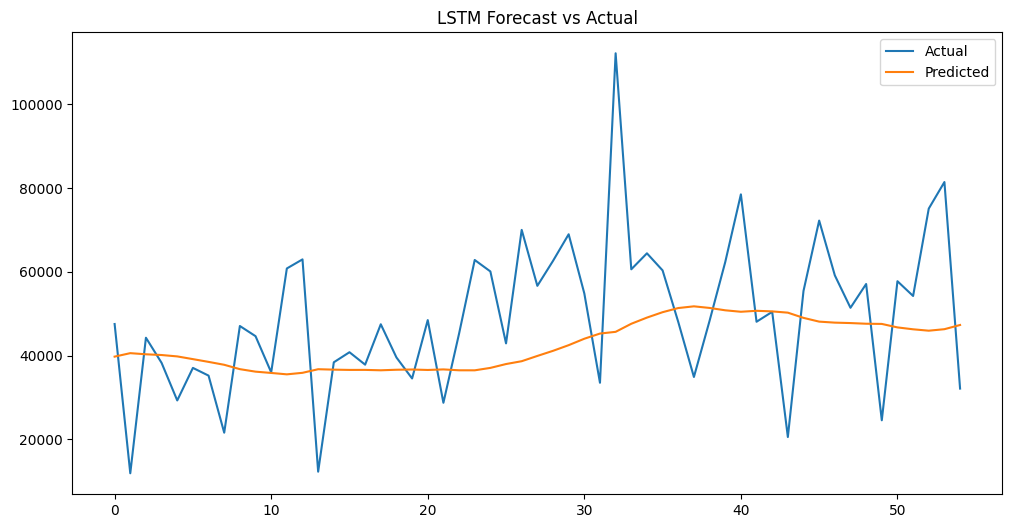

In [16]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.title("LSTM Forecast vs Actual")

plt.show()

In [18]:
import joblib 

model.save("../models/lstm_model.keras")

In [19]:
results = pd.DataFrame({
    'actual': y_test_actual.flatten(),
    'predicted': predictions.flatten()
})

results.to_csv("../data/forecasting/lstm_predictions.csv",index=False)

In [20]:
import mlflow

mlflow.set_experiment("RetailPulse")

with mlflow.start_run(run_name="LSTM_Model"):

    mlflow.log_param("model_type", "LSTM")

    mlflow.log_param("sequence_length", sequence_length)

    mlflow.log_param("epochs", 20)

    mlflow.log_param("batch_size", 32)

    mlflow.log_metric("MAE", mae)

    mlflow.log_metric("RMSE", rmse)

    mlflow.log_metric("MAPE", mape)

print("LSTM model logged successfully")

LSTM model logged successfully
